# 11.3 — FVA, ColVA, MVA/KVA (panorama)

Panorama de los XVAs restantes: cada uno ajusta el valor de un derivado por un costo de
**financiamiento** distinto, con la misma estructura matemática de CVA (11.2) — integrar
la exposición esperada contra un spread, en vez de contra una densidad de default.

## 0. Configuración

Reusa (redefinido localmente) la exposición del swap 5Y de 11.1/11.2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
payment_times_A = np.arange(1.0, 6.0)
K_A = par_swap_rate(nelson_siegel_df, payment_times_A)
n_paths = 200_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value_remaining(t, r_t, K, all_payment_times, a, sigma):
    remaining = all_payment_times[all_payment_times > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    return (1.0 - dfs[-1]) - K * np.sum(tau[:, None] * dfs, axis=0)


def ou_exact_joint(a, sigma, t, n_paths, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, 2))
    s = Z @ L.T
    return s[:, 0]


def simulate_short_rate(t, a, sigma, n_paths, rng):
    x_t = ou_exact_joint(a, sigma, t, n_paths, rng)
    alpha_t = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    return instantaneous_forward(t) + alpha_t + x_t


EE_pos, EE_neg = [], []
for t in check_times:
    r_t = simulate_short_rate(t, a, sigma, n_paths, rng)
    V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
    EE_pos.append(np.maximum(V, 0.0).mean())
    EE_neg.append(np.maximum(-V, 0.0).mean())
EE_pos, EE_neg = np.array(EE_pos), np.array(EE_neg)

## 1. FVA: costo/beneficio de financiamiento

Estructuralmente análogo a CVA/DVA, pero integrando el **spread de funding propio**
(no una intensidad de default) contra la exposición: financiar una posición no
colateralizada cuesta (o beneficia) el spread al que la entidad se fondea por encima
(o por debajo) de la tasa libre de riesgo.
$$\text{FVA} \approx \sum_i P(0,T_i)\,s_{\text{funding}}(T_i)\,EE^+(T_i)\,\Delta_i$$
(exposición positiva: financiar el activo que representa el derivado cuando está a favor)
más el término simétrico con $EE^-$ y el spread de funding pasivo, aquí agregados en un
solo término neto por simplicidad.

In [3]:
s_funding = 0.005  # 50bp de spread de funding propio


def integrate_against_ee(EE, check_times, spread_or_diff, disc_curve):
    deltas = np.diff(np.concatenate([[0.0], check_times]))
    discs = disc_curve(check_times)
    return np.sum(discs * spread_or_diff * EE * deltas)


fva = integrate_against_ee(EE_pos, check_times, s_funding, nelson_siegel_df)
print(f"FVA (spread de funding={s_funding:.2%}): {fva:.6f}")

fva_zero_spread = integrate_against_ee(EE_pos, check_times, 0.0, nelson_siegel_df)
print(f"FVA con spread de funding=0 (control): {fva_zero_spread:.2e}")

FVA (spread de funding=0.50%): 0.000269
FVA con spread de funding=0 (control): 0.00e+00


## 2. ColVA: diferencial de tasa de colateral

Mismo mecanismo: si el colateral posteado se remunera a una tasa distinta de la de
descuento del derivado, el diferencial se integra contra la exposición.

ColVA (diferencial de colateral=0.20%): 0.000108
ColVA con diferencial=0 (control): 0.00e+00


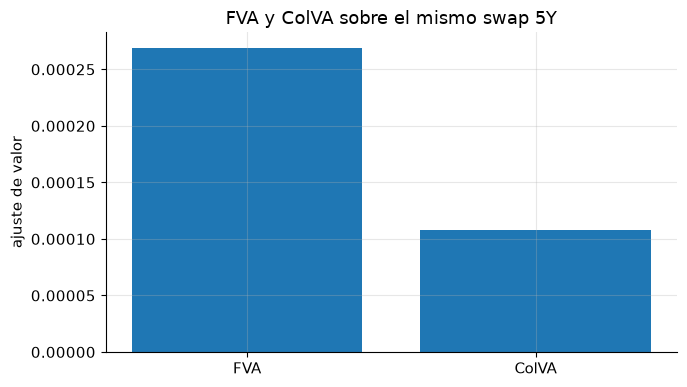

In [4]:
collateral_rate_diff = 0.002  # 20bp de diferencial (tasa de colateral vs OIS de descuento)

colva = integrate_against_ee(EE_pos, check_times, collateral_rate_diff, nelson_siegel_df)
print(f"ColVA (diferencial de colateral={collateral_rate_diff:.2%}): {colva:.6f}")

colva_zero_diff = integrate_against_ee(EE_pos, check_times, 0.0, nelson_siegel_df)
print(f"ColVA con diferencial=0 (control): {colva_zero_diff:.2e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["FVA", "ColVA"], [fva, colva])
ax.set_ylabel("ajuste de valor")
ax.set_title("FVA y ColVA sobre el mismo swap 5Y")
fig.tight_layout(); plt.show()

## 3. MVA/KVA: panorama (sin implementación completa)

**MVA** (Margin Valuation Adjustment): costo de financiar el **Initial Margin** exigido
por regulación (post-2008, para derivados no compensados centralmente o vía CCP con
requerimientos de margen inicial) — requiere simular el perfil FUTURO del propio
requerimiento de IM, que a su vez típicamente se calcula como un VaR (o SIMM, la
metodología estándar de ISDA) de la exposición futura del portafolio en cada fecha: un
cálculo de "exposición sobre la exposición" (anticipa el VaR de M12) que excede el
alcance de un notebook introductorio de panorama.

**KVA** (Capital Valuation Adjustment): costo del capital regulatorio que el banco debe
mantener contra la posición (Basel III/IV), descontado a lo largo de la vida del trade —
requiere simular el perfil futuro del requerimiento de capital regulatorio (que depende
de EAD, PD, LGD bajo el marco regulatorio vigente), un cálculo que combina crédito (M10),
exposición (11.1) y una capa regulatoria completa fuera del alcance de este currículum.

Ambos se mencionan por completitud (son estándar en cualquier desk de XVA moderno) sin
implementación numérica — a diferencia de FVA/ColVA (mecanismo idéntico a CVA, sólo
cambia qué se integra), MVA/KVA requieren un objeto adicional (el perfil futuro de
margen/capital) que no se deriva de nada ya construido en este currículum.

## 4. Validación

Único chequeo numérico duro de este notebook: FVA y ColVA deben anularse exactamente cuando su spread o diferencial de entrada es cero (una identidad algebraica de la fórmula de integración, no un test estadístico). MVA/KVA quedan sin assert de pricing — son exploratorios por diseño, como se explicó en la Sección 3.

In [5]:
check1 = abs(fva_zero_spread) < 1e-10
print(f"1. FVA con spread=0 se anula exactamente: {fva_zero_spread:.2e} (<1e-10? {check1})")

check2 = abs(colva_zero_diff) < 1e-10
print(f"2. ColVA con diferencial=0 se anula exactamente: {colva_zero_diff:.2e} (<1e-10? {check2})")

assert check1
assert check2
print("\nValidacion completa: 2/2 dentro de tolerancia (unico chequeo numerico duro de esta seccion;")
print("MVA/KVA son exploratorios/panorama por diseno, sin assert de pricing -- ver Seccion 3).")

1. FVA con spread=0 se anula exactamente: 0.00e+00 (<1e-10? True)
2. ColVA con diferencial=0 se anula exactamente: 0.00e+00 (<1e-10? True)

Validacion completa: 2/2 dentro de tolerancia (unico chequeo numerico duro de esta seccion;
MVA/KVA son exploratorios/panorama por diseno, sin assert de pricing -- ver Seccion 3).


## Referencias

- Green, A. (2015). *XVA: Credit, Funding and Capital Valuation Adjustments*, cap. 11-14
  (FVA, ColVA, MVA, KVA).
- Albanese, C., Andersen, L., Iabichino, S. (2015). *FVA: a real option*. Risk.